# Artificial Intelligence
# 464
# Project #4

## Before You Begin...
00. We're using a Jupyter Notebook environment (tutorial available here: https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html),
01. Read the entire notebook before beginning your work, and
02.  Check the submission deadline on Gradescope.


## General Directions for this Assignment
00. Output format should be exactly as requested,
01. Functions should do only one thing,
02. Keep functions to 20 lines or less (empty lines are fine, there's leeway, but don't blatantly ignore this),
03. Add docstring to all functions,


## Before You Submit...
00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import networkx as nx
from copy import deepcopy

You might need to do a install to work with networkx

```
pip install networkx
```

## Map Coloring

It turns out that any division of a plane into contiguous regions can be colored such that no two adjacent regions are the same color by using only four colors (see [Four Color Theorem](http://en.wikipedia.org/wiki/Four_color_theorem), for more details) This **Constraint Satisfaction Problem** can be viewed as a constraint graph, where variables are nodes and no adjacent nodes can be of the same color.


Our first constraint graph is the dictionary `connecticut_graph` with three keys: 1) "nodes," which is a ordered list of strings that represent the nodes; 2) "edges," which indicates with tuples which nodes are adjacent; and 3) the "coordinates" key helps NetworkX make cartoons.

In [2]:
connecticut_graph = { "nodes": ["Fairfield", "Litchfield", "New Haven", "Hartford", "Middlesex", "Tolland", "New London", "Windham"],
                "edges": [(0,1), (0,2), (1,2), (1,3), (2,3), (2,4), (3,4), (3,5), (3,6), (4,6), (5,6), (5,7), (6,7)],
                "coordinates": [( 46, 52), ( 65,142), (104, 77), (123,142), (147, 85), (162,140), (197, 94), (217,146)]}
print(connecticut_graph)

{'nodes': ['Fairfield', 'Litchfield', 'New Haven', 'Hartford', 'Middlesex', 'Tolland', 'New London', 'Windham'], 'edges': [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5), (3, 6), (4, 6), (5, 6), (5, 7), (6, 7)], 'coordinates': [(46, 52), (65, 142), (104, 77), (123, 142), (147, 85), (162, 140), (197, 94), (217, 146)]}


In [3]:
def backtrack_color(curr_node, assigned_colors, nodes, adjacency_list, available_colors, trace=False):
    """
    Backtracking algorithm to assign colors to nodes in a constraint graph.

    Parameters:
    - curr_node (str): The current node being colored.
    - assigned_colors (dict): Dictionary mapping nodes to assigned colors.
    - nodes (list): List of all nodes in the graph.
    - adjacency_list (dict): Dictionary mapping each node to its neighboring nodes.
    - available_colors (list): List of allowed colors.
    - trace (bool): If True, prints debug statements.

    Returns:
    - list of tuples: A valid coloring solution [(node, color), ...] or None if no solution exists.
    """
    if len(assigned_colors) == len(nodes): 
        return [(node, assigned_colors[node]) for node in nodes]

    for color in order_colors_lcv(curr_node, assigned_colors, available_colors, adjacency_list, trace):
        if not forward_checking(curr_node, color, assigned_colors, adjacency_list, trace):
            continue
        
        assigned_colors[curr_node] = color
        if trace:
            print(f"Color {color} assigned to node {curr_node}")

        next_node = select_mrv_node(assigned_colors, adjacency_list, available_colors, nodes, trace)
        if next_node is None: 
            return [(node, assigned_colors[node]) for node in nodes]

        solution = backtrack_color(next_node, assigned_colors, nodes, adjacency_list, available_colors, trace)
        if solution:
            return solution

        if trace:
            print(f"Backtracking: removing color {color} from node {curr_node}")
        del assigned_colors[curr_node] 

    return None 

def forward_checking(curr_node, color, assigned_colors, adjacency_list, trace=False):
    """
    Ensures that assigning a color does not violate constraints with adjacent nodes.

    Parameters:
    - curr_node (str): Node being colored.
    - color (str): Color being considered.
    - assigned_colors (dict): Dictionary mapping nodes to their assigned colors.
    - adjacency_list (dict): Dictionary of node neighbors.
    - trace (bool): If True, prints debug statements.

    Returns:
    - bool: True if color can be assigned, False otherwise.
    """
    conflicting_neighbors = [
        neighbor for neighbor in adjacency_list[curr_node]
        if assigned_colors.get(neighbor) == color
    ]
    if conflicting_neighbors:
        if trace:
            print(f"Conflict detected: Node(s) {', '.join(conflicting_neighbors)} "
                  f"already colored with {color}. Cannot assign to {curr_node}.")
        return False
    return True

def select_degree_node(assigned_colors, nodes, adjacency_list, trace=False):
    """
    Selects the next uncolored node using the Degree Heuristic (most constrained node first).

    Parameters:
    - assigned_colors (dict): Dictionary of assigned colors.
    - nodes (list): List of all nodes.
    - adjacency_list (dict): Dictionary of node neighbors.
    - trace (bool): If True, prints debug statements.

    Returns:
    - str: The selected node.
    """
    uncolored_nodes = [node for node in nodes if node not in assigned_colors]
    max_degree_node = max(uncolored_nodes, key=lambda node: len(adjacency_list[node]), default=None)
    if trace:
        print(f"Node selected by degree heuristic: {max_degree_node}")
    return max_degree_node

def order_colors_lcv(curr_node, assigned_colors, available_colors, adjacency_list, trace=False):
    """
    Orders colors using the Least Constraining Value (LCV) heuristic.

    Parameters:
    - curr_node (str): The node to be colored.
    - assigned_colors (dict): Dictionary of assigned colors.
    - available_colors (list): List of available colors.
    - adjacency_list (dict): Dictionary of node neighbors.
    - trace (bool): If True, prints debug statements.

    Returns:
    - list: Available colors sorted by least constraint impact.
    """
    color_conflicts = {color: 0 for color in available_colors}
    for neighbor in adjacency_list[curr_node]:
        if neighbor in assigned_colors:
            color_conflicts[assigned_colors[neighbor]] += 1
    if trace:
        print(f"Colors for node {curr_node} ordered by least constraints: {color_conflicts}")
    return sorted(available_colors, key=lambda color: color_conflicts[color])

def select_mrv_node(assigned_colors, adjacency_list, available_colors, nodes, trace=False):
    """
    Selects the next node using the Minimum Remaining Values (MRV) heuristic.

    Parameters:
    - assigned_colors (dict): Dictionary of assigned colors.
    - adjacency_list (dict): Dictionary of node neighbors.
    - available_colors (list): List of available colors.
    - nodes (list): List of all nodes.
    - trace (bool): If True, prints debug statements.

    Returns:
    - str: The selected node.
    """
    uncolored_nodes = [node for node in nodes if node not in assigned_colors]
    if not uncolored_nodes:
        return None
    
    min_node = None
    min_remaining_count = float('inf')
    
    for node in uncolored_nodes:
        used_colors = {assigned_colors[neighbor] for neighbor in adjacency_list[node] if neighbor in assigned_colors}
        remaining_colors_count = len(available_colors) - len(used_colors)
        if remaining_colors_count < min_remaining_count:
            min_remaining_count = remaining_colors_count
            min_node = node
    
    if trace:
        print(f"Node chosen by MRV heuristic: {min_node} with {min_remaining_count} remaining colors")
    
    return min_node

def color_map(constraint_graph, color_list, trace=False):
    """
    This function colors a map provided as a constraint graph (dict keys: nodes, edges, and coordinate)
    The inputs are the constraint graph and a list of colors. 
    Implementation should feature: 
    1) Backtracking, 2) Forward Checking, 3) variables picked using MRV, and 4) Values picked using LCV. 
    Each feature should be its own helper function.  
    The trace is a flag that when set to True, prints out statements that state what the algorithm
    is currently doing (in terms of the four features)
    Return a list of (node name, assigned color) tuples, where 
    the ordering matches the original ordering of nodes in the constraint_graph. 
    For example, if we had `["A", "B"]` as nodes and `["Yellow", "Green"]` as colors, 
    your function might return `[("A", "Yellow"), ("B", "Green")]`
    If the CSP cannot find a solution, `None` is returned.
    """
    neighbors = {node: [] for node in constraint_graph["nodes"]}
    for node1, node2 in constraint_graph["edges"]:
        node1_name = constraint_graph["nodes"][node1]
        node2_name = constraint_graph["nodes"][node2]
        neighbors[node1_name].append(node2_name)
        neighbors[node2_name].append(node1_name)
    curr_node = select_degree_node({}, constraint_graph["nodes"], neighbors)
    return backtrack_color(curr_node, {}, constraint_graph['nodes'], neighbors, color_list, trace)


In [4]:
def test_coloring(constraint_graph, solution):
    """
    This function tests the solution resulting from `color_map`. 
    Adjacent nodes in the solution cannot be of the same color.
    constraint_graph is the dict with keys: nodes, edges, and coordinates.
    solution is a list of (node name, assigned color) tuples
    Returns a warning statement if there's a violation
    """
    nodes = constraint_graph[ "nodes"]
    edges = constraint_graph["edges"]
    for start, end in edges:
        try:
            assert solution[start][1] != solution[end][1]
        except AssertionError:
            print(f"{nodes[start]} and {nodes[end]} are adjacent but have the same color.")

In [5]:
def draw_map(title, constraint_graph, size, solution=None):
    """
    This function uses Networkx to draw the `constraint_graph` (dict keys: nodes, edges, and coordinate) 
    Nodes are colored using `solution`, a list of (node name, assigned color) tuples
    title is the title for the cartoon
    size is in inches wide x inches tall, so (8,10) results in 8"x10" rendering (depends on monitor)
    """
    
    def as_dictionary(a_list):
        dct = {}
        for i, e in enumerate(a_list):
            dct[i] = e
        return dct
    
    G = nx.Graph()
    
    labels = as_dictionary(constraint_graph["nodes"])
    pos = as_dictionary(constraint_graph["coordinates"])
    
    # create a List of Nodes as indices to match the "edges" entry.
    nodes = [n for n in range(0, len(constraint_graph["nodes"]))]

    if solution:
        colors = [c for n, c in solution]
    else:
        colors = ['red' for c in range(0,len(constraint_graph["nodes"]))]

    G.add_nodes_from(nodes)
    G.add_edges_from(constraint_graph["edges"])

    plt.figure(figsize=size, dpi=100)
    plt.title(title)
    nx.draw(G, node_color = colors, with_labels = True, labels = labels, pos = pos)
    
#    plt.savefig(name + ".png")

## Problem 1. Color Connecticut with Four Colors

In [6]:
connecticut_solution = color_map(connecticut_graph, ["red", "blue", "green", "yellow"], trace=True)

Colors for node Hartford ordered by least constraints: {'red': 0, 'blue': 0, 'green': 0, 'yellow': 0}
Color red assigned to node Hartford
Node chosen by MRV heuristic: Litchfield with 3 remaining colors
Colors for node Litchfield ordered by least constraints: {'red': 1, 'blue': 0, 'green': 0, 'yellow': 0}
Color blue assigned to node Litchfield
Node chosen by MRV heuristic: New Haven with 2 remaining colors
Colors for node New Haven ordered by least constraints: {'red': 1, 'blue': 1, 'green': 0, 'yellow': 0}
Color green assigned to node New Haven
Node chosen by MRV heuristic: Fairfield with 2 remaining colors
Colors for node Fairfield ordered by least constraints: {'red': 0, 'blue': 1, 'green': 1, 'yellow': 0}
Color red assigned to node Fairfield
Node chosen by MRV heuristic: Middlesex with 2 remaining colors
Colors for node Middlesex ordered by least constraints: {'red': 1, 'blue': 0, 'green': 1, 'yellow': 0}
Color blue assigned to node Middlesex
Node chosen by MRV heuristic: New Londo

## Test Connecticut Solution

In [7]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

## Draw Connecticut Cartoon

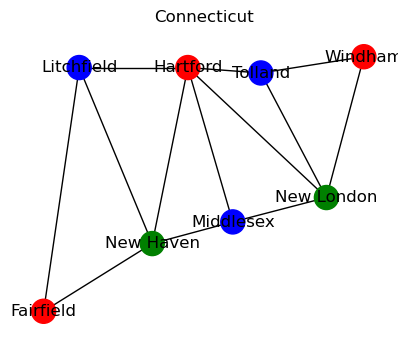

In [8]:
if connecticut_solution:
    draw_map("Connecticut", connecticut_graph, (5,4), connecticut_solution)

## Problem 2. Color Connecticut with Three Colors

In [9]:
connecticut_solution = color_map(connecticut_graph, ["red", "blue", "green"], trace=True)

Colors for node Hartford ordered by least constraints: {'red': 0, 'blue': 0, 'green': 0}
Color red assigned to node Hartford
Node chosen by MRV heuristic: Litchfield with 2 remaining colors
Colors for node Litchfield ordered by least constraints: {'red': 1, 'blue': 0, 'green': 0}
Color blue assigned to node Litchfield
Node chosen by MRV heuristic: New Haven with 1 remaining colors
Colors for node New Haven ordered by least constraints: {'red': 1, 'blue': 1, 'green': 0}
Color green assigned to node New Haven
Node chosen by MRV heuristic: Fairfield with 1 remaining colors
Colors for node Fairfield ordered by least constraints: {'red': 0, 'blue': 1, 'green': 1}
Color red assigned to node Fairfield
Node chosen by MRV heuristic: Middlesex with 1 remaining colors
Colors for node Middlesex ordered by least constraints: {'red': 1, 'blue': 0, 'green': 1}
Color blue assigned to node Middlesex
Node chosen by MRV heuristic: New London with 1 remaining colors
Colors for node New London ordered by l

## Test Connecticut Solution

In [10]:
if connecticut_solution:
    test_coloring(connecticut_graph, connecticut_solution)

## Draw Connecticut Cartoon

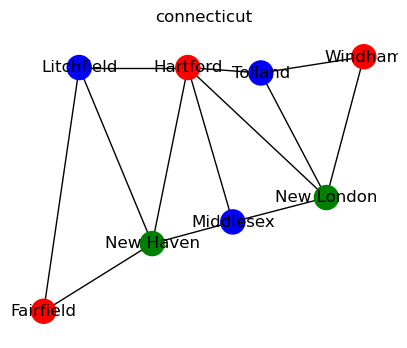

In [11]:
if connecticut_solution:
    draw_map("connecticut", connecticut_graph, (5,4), connecticut_solution)

## Problem 3. Color Europe with Four Colors

In [12]:
europe_graph = {
    "nodes":  ["Iceland", "Ireland", "United Kingdom", "Portugal", "Spain",
                 "France", "Belgium", "Netherlands", "Luxembourg", "Germany",
                 "Denmark", "Norway", "Sweden", "Finland", "Estonia",
                 "Latvia", "Lithuania", "Poland", "Czech Republic", "Austria",
                 "Liechtenstein", "Switzerland", "Italy", "Malta", "Greece",
                 "Albania", "Macedonia", "Kosovo", "Montenegro", "Bosnia Herzegovina",
                 "Serbia", "Croatia", "Slovenia", "Hungary", "Slovakia",
                 "Belarus", "Ukraine", "Moldova", "Romania", "Bulgaria",
                 "Cyprus", "Turkey", "Georgia", "Armenia", "Azerbaijan",
                 "Russia" ], 
    "edges": [(0,1), (0,2), (1,2), (2,5), (2,6), (2,7), (2,11), (3,4),
                 (4,5), (4,22), (5,6), (5,8), (5,9), (5,21), (5,22),(6,7),
                 (6,8), (6,9), (7,9), (8,9), (9,10), (9,12), (9,17), (9,18),
                 (9,19), (9,21), (10,11), (10,12), (10,17), (11,12), (11,13), (11,45), 
                 (12,13), (12,14), (12,15), (12,17), (13,14), (13,45), (14,15),
                 (14,45), (15,16), (15,35), (15,45), (16,17), (16,35), (17,18),
                 (17,34), (17,35), (17,36), (18,19), (18,34), (19,20), (19,21), 
                 (19,22), (19,32), (19,33), (19,34), (20,21), (21,22), (22,23),
                 (22,24), (22,25), (22,28), (22,29), (22,31), (22,32), (24,25),
                 (24,26), (24,39), (24,40), (24,41), (25,26), (25,27), (25,28),
                 (26,27), (26,30), (26,39), (27,28), (27,30), (28,29), (28,30),
                 (29,30), (29,31), (30,31), (30,33), (30,38), (30,39), (31,32),
                 (31,33), (32,33), (33,34), (33,36), (33,38), (34,36), (35,36),
                 (35,45), (36,37), (36,38), (36,45), (37,38), (38,39), (39,41),
                 (40,41), (41,42), (41,43), (41,44), (42,43), (42,44), (42,45),
                 (43,44), (44,45)],
    "coordinates": [( 18,147), ( 48, 83), ( 64, 90), ( 47, 28), ( 63, 34),
                   ( 78, 55), ( 82, 74), ( 84, 80), ( 82, 69), (100, 78),
                   ( 94, 97), (110,162), (116,144), (143,149), (140,111),
                   (137,102), (136, 95), (122, 78), (110, 67), (112, 60),
                   ( 98, 59), ( 93, 55), (102, 35), (108, 14), (130, 22),
                   (125, 32), (128, 37), (127, 40), (122, 42), (118, 47),
                   (127, 48), (116, 53), (111, 54), (122, 57), (124, 65),
                   (146, 87), (158, 65), (148, 57), (138, 54), (137, 41),
                   (160, 13), (168, 29), (189, 39), (194, 32), (202, 33),
                   (191,118)]}
print(europe_graph)

{'nodes': ['Iceland', 'Ireland', 'United Kingdom', 'Portugal', 'Spain', 'France', 'Belgium', 'Netherlands', 'Luxembourg', 'Germany', 'Denmark', 'Norway', 'Sweden', 'Finland', 'Estonia', 'Latvia', 'Lithuania', 'Poland', 'Czech Republic', 'Austria', 'Liechtenstein', 'Switzerland', 'Italy', 'Malta', 'Greece', 'Albania', 'Macedonia', 'Kosovo', 'Montenegro', 'Bosnia Herzegovina', 'Serbia', 'Croatia', 'Slovenia', 'Hungary', 'Slovakia', 'Belarus', 'Ukraine', 'Moldova', 'Romania', 'Bulgaria', 'Cyprus', 'Turkey', 'Georgia', 'Armenia', 'Azerbaijan', 'Russia'], 'edges': [(0, 1), (0, 2), (1, 2), (2, 5), (2, 6), (2, 7), (2, 11), (3, 4), (4, 5), (4, 22), (5, 6), (5, 8), (5, 9), (5, 21), (5, 22), (6, 7), (6, 8), (6, 9), (7, 9), (8, 9), (9, 10), (9, 12), (9, 17), (9, 18), (9, 19), (9, 21), (10, 11), (10, 12), (10, 17), (11, 12), (11, 13), (11, 45), (12, 13), (12, 14), (12, 15), (12, 17), (13, 14), (13, 45), (14, 15), (14, 45), (15, 16), (15, 35), (15, 45), (16, 17), (16, 35), (17, 18), (17, 34), (17, 

In [13]:
europe_solution = color_map(europe_graph, ["red", "blue", "green", "yellow"], trace=False)

## Test Europe Solution

In [14]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

## Draw Europe Cartoon

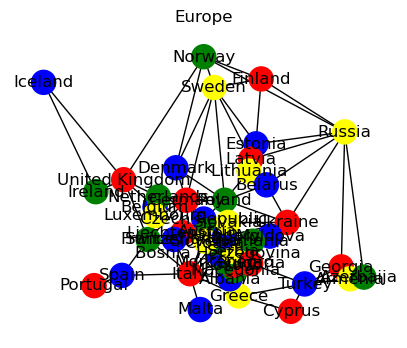

In [15]:
if europe_solution:
    draw_map("Europe", europe_graph, (5,4), europe_solution)

## Problem 4. Color Europe with Three Colors

In [16]:
europe_solution = color_map(europe_graph, ["red", "blue", "green"], trace=False)

## Test Europe Solution

In [17]:
if europe_solution:
    test_coloring(europe_graph, europe_solution)

## Draw Europe Cartoon

In [18]:
if europe_solution:
    draw_map("Europe", europe_graph, (5,4), europe_solution)

## Before You Submit...

00. Re-read the general instructions provided above, and
01. Hit "Kernel"->"Restart & Run All". The first cell that is run should show [1], the second should show [2], and so on...
02. Submit your notebook (as .ipynb, not PDF) using Gradescope, and
03.  Do not submit any other files.